<a href="https://colab.research.google.com/github/saleemabegam34-ops/rdkit_project.ipynb/blob/main/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
data = {
    "title": [
        "Cancer immunotherapy using antibodies",
        "mRNA vaccine for infectious disease",
        "Nanoparticle drug delivery system",
        "Tumor targeting antibody therapy",
        "CRISPR gene editing method",
        "mRNA lipid nanoparticle vaccine",
        "Cancer cell inhibition compound",
        "Targeted drug delivery system"
    ],
    "abstract": [
        "Antibody-based cancer treatment method",
        "mRNA vaccines for virus protection",
        "Nanoparticles improve drug delivery",
        "Antibodies target tumor cells",
        "Gene editing using CRISPR",
        "mRNA delivery using lipid particles",
        "Compound inhibits cancer cells",
        "Efficient targeted drug delivery"
    ]
}

df = pd.DataFrame(data)
df.to_csv("data.csv", index=False)

In [3]:
df = pd.read_csv("data.csv")

df["text"] = df["title"] + " " + df["abstract"]

print(df.head())

                                   title  \
0  Cancer immunotherapy using antibodies   
1    mRNA vaccine for infectious disease   
2      Nanoparticle drug delivery system   
3       Tumor targeting antibody therapy   
4             CRISPR gene editing method   

                                 abstract  \
0  Antibody-based cancer treatment method   
1      mRNA vaccines for virus protection   
2     Nanoparticles improve drug delivery   
3           Antibodies target tumor cells   
4               Gene editing using CRISPR   

                                                text  
0  Cancer immunotherapy using antibodies Antibody...  
1  mRNA vaccine for infectious disease mRNA vacci...  
2  Nanoparticle drug delivery system Nanoparticle...  
3  Tumor targeting antibody therapy Antibodies ta...  
4  CRISPR gene editing method Gene editing using ...  


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["text"])

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df["cluster"] = kmeans.fit_predict(X)

print(df[["text", "cluster"]])

                                                text  cluster
0  Cancer immunotherapy using antibodies Antibody...        2
1  mRNA vaccine for infectious disease mRNA vacci...        1
2  Nanoparticle drug delivery system Nanoparticle...        0
3  Tumor targeting antibody therapy Antibodies ta...        2
4  CRISPR gene editing method Gene editing using ...        2
5  mRNA lipid nanoparticle vaccine mRNA delivery ...        1
6  Cancer cell inhibition compound Compound inhib...        2
7  Targeted drug delivery system Efficient target...        0


In [6]:
import numpy as np

In [7]:
terms = vectorizer.get_feature_names_out()

for i in range(3):
    center = kmeans.cluster_centers_[i]
    top_words = [terms[j] for j in center.argsort()[-5:]]

    print(f"\nCluster {i} Top Words:")
    print(top_words)


Cluster 0 Top Words:
['improve', 'nanoparticles', 'targeted', 'delivery', 'drug']

Cluster 1 Top Words:
['disease', 'virus', 'vaccine', 'lipid', 'mrna']

Cluster 2 Top Words:
['antibody', 'antibodies', 'compound', 'tumor', 'cancer']


In [8]:
import matplotlib.pyplot as plt

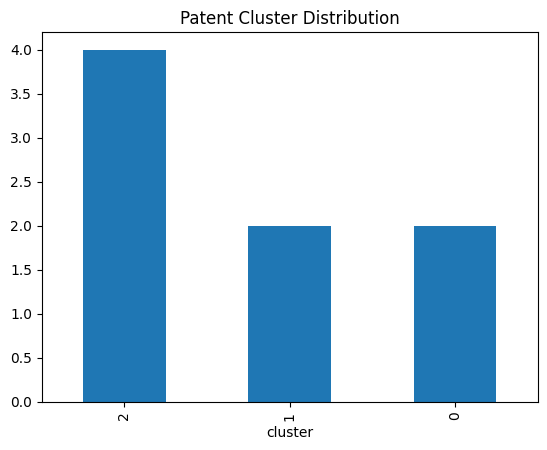

In [9]:
df["cluster"].value_counts().plot(kind="bar")
plt.title("Patent Cluster Distribution")
plt.show()